In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [59]:
df = sns.load_dataset('titanic')

In [60]:
df.shape

(891, 15)

In [61]:
df.to_csv('dataset.csv') 

In [62]:
df = pd.read_csv("dataset.csv")

In [63]:
df.shape

(891, 16)

In [64]:
df.head(2)

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [65]:
df.columns

Index(['Unnamed: 0', 'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch',
       'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [66]:
df = df.drop(columns=['Unnamed: 0','pclass','sibsp','parch','embarked','who','adult_male','deck','survived','alone'])

In [67]:
df.head(3)

,sex,age,fare,class,embark_town,alive
0,male,22.0,7.2500,Third,Southampton,no
1,female,38.0,71.2833,First,Cherbourg,yes
2,female,26.0,7.9250,Third,Southampton,yes


In [68]:
df.isnull().sum()

sex              0
age            177
fare             0
class            0
embark_town      2
alive            0
dtype: int64

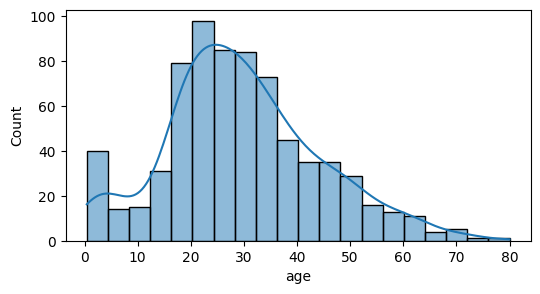

In [69]:
plt.figure(figsize=(6,3))
sns.histplot( df['age'] , kde=True )
plt.show()

In [70]:
df = df.ffill()

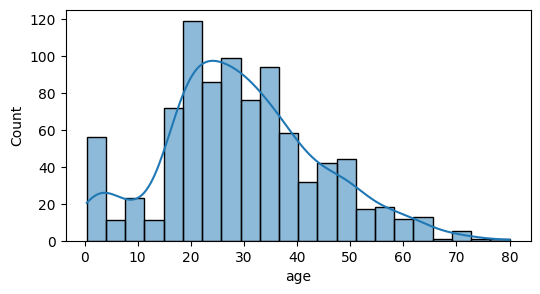

In [71]:
plt.figure(figsize=(6,3))
sns.histplot( df['age'] , kde=True )
plt.show()

In [72]:
df.isnull().sum()

sex            0
age            0
fare           0
class          0
embark_town    0
alive          0
dtype: int64

In [73]:
df['alive'].value_counts().yes

np.int64(342)

In [74]:
df['alive'].value_counts().get('yes',0)

np.int64(342)

In [75]:
df.shape

(891, 6)

In [76]:
df.columns

Index(['sex', 'age', 'fare', 'class', 'embark_town', 'alive'], dtype='object')

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          891 non-null    object 
 1   age          891 non-null    float64
 2   fare         891 non-null    float64
 3   class        891 non-null    object 
 4   embark_town  891 non-null    object 
 5   alive        891 non-null    object 
dtypes: float64(2), object(4)
memory usage: 41.9+ KB


In [78]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].map( lambda val : list(df[col].unique()).index(val) )

In [79]:
df.head(3)

,sex,age,fare,class,embark_town,alive
0,0,22.0,7.2500,0,0,0
1,1,38.0,71.2833,1,1,1
2,1,26.0,7.9250,0,0,1


In [80]:
from sklearn.preprocessing import StandardScaler

In [81]:
scaler = StandardScaler()
for col in df.select_dtypes(include='float').columns:
    df[col] = scaler.fit_transform(df[[col]])

In [82]:
df.head(3)

,sex,age,fare,class,embark_town,alive
0,0,-0.521198,-0.502445,0,0,0
1,1,0.578729,0.786845,1,1,1
2,1,-0.246216,-0.488854,0,0,1
